# Telco Customer Churn — Exploratory Data Analysis

**Goal:** understand who churns and why, and turn each finding into a concrete modeling
decision *before* writing any model. The dataset is the public IBM Telco Customer Churn
sample (7,043 customers, 20 features + a binary `Churn` target).

Every section below ends with a **Modeling implication** — EDA is only useful if it
changes what we do next.

In [1]:
import sys
from pathlib import Path

# Make the project's src package importable when the notebook runs from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, load_clean

sns.set_theme(style="whitegrid")
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 40)

## 1. Shape, dtypes, and a first look

In [2]:
raw = load_raw()
print("shape:", raw.shape)
raw.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

**Finding.** `TotalCharges` is stored as `object`, not a number — a red flag. Every
other column is either a clean numeric or a low-cardinality category.

**Modeling implication.** Something non-numeric is hiding in `TotalCharges`; we must find
and handle it deliberately before it silently breaks scaling or arithmetic.

## 2. Missingness and the TotalCharges trap

In [4]:
# TotalCharges won't convert cleanly — expose exactly which rows resist.
coerced = pd.to_numeric(raw["TotalCharges"], errors="coerce")
bad = raw[coerced.isna()]
print("rows where TotalCharges is not numeric:", len(bad))
print("their tenure values:", sorted(bad["tenure"].unique()))
bad[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

rows where TotalCharges is not numeric: 11
their tenure values: [0]


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Finding.** Exactly 11 rows have a blank `TotalCharges`, and **all 11 have
`tenure == 0`** — brand-new customers who have not yet been through a billing cycle.
There is no other missingness in the dataset.

**Modeling implication.** These are not corrupt rows to drop. A customer with zero tenure
has genuinely accrued **$0** in total charges, so the correct fill is `0`, not the column
mean (which would invent ~$2,000 of spend). This is handled in `src/data.py`.

In [5]:
df = load_clean()  # cleaned frame: TotalCharges numeric, customerID dropped, Churn -> 1/0
print("clean shape:", df.shape)
print("any nulls left:", bool(df.isna().any().any()))
df.describe()

clean shape: (7043, 20)
any nulls left: False


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## 3. Class balance — the headline constraint

Churn
stay     5174
churn    1869
Name: count, dtype: int64
churn rate: 0.2654


/var/folders/hd/0vq762q50d940br5p059czv40000gn/T/ipykernel_16993/2584931943.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#2ca02c", "#d62728"])


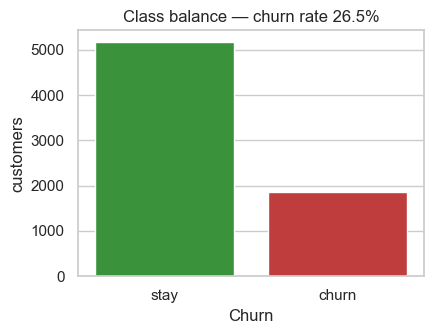

In [6]:
churn_rate = df["Churn"].mean()
counts = df["Churn"].value_counts().rename({0: "stay", 1: "churn"})
print(counts)
print(f"churn rate: {churn_rate:.4f}")

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#2ca02c", "#d62728"])
ax.set_title(f"Class balance — churn rate {churn_rate:.1%}")
ax.set_ylabel("customers")
fig.tight_layout()
fig.savefig(FIG_DIR / "class_balance.png", dpi=120)
plt.show()

**Finding.** Churn is **~26.5%** of customers — a roughly 1:2.8 minority class.

**Modeling implication.** This single number drives three later decisions:
1. **Never report accuracy as the headline** — predicting "nobody churns" already scores
   ~73.5%. We use **PR-AUC** (average precision) plus recall on the churn class.
2. **Handle the imbalance in the loss**, via `class_weight='balanced'` (LR/RF) and
   `scale_pos_weight` (XGB), so missed churners are paid for.
3. **Stratify** every split and CV fold so each holds the real 26.5% base rate.

## 4. Tenure — the strongest single driver

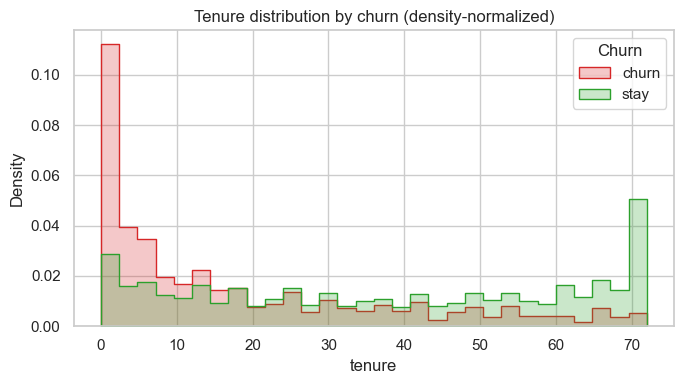

Churn
stay     38.0
churn    10.0
Name: tenure, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
# common_norm=False normalizes each churn group to its OWN density (area=1 per class) instead
# of sharing one total. With a 3:1 class imbalance a shared norm would flatten the small churn
# group into near-invisibility; per-class density lets us compare the SHAPE of the two tenure
# distributions fairly, which is the point of this plot.
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, element="step",
             stat="density", common_norm=False,
             palette={0: "#2ca02c", 1: "#d62728"}, ax=ax)
ax.set_title("Tenure distribution by churn (density-normalized)")
ax.legend(title="Churn", labels=["churn", "stay"])
fig.tight_layout()
fig.savefig(FIG_DIR / "tenure_by_churn.png", dpi=120)
plt.show()

print(df.groupby("Churn")["tenure"].median().rename({0: "stay", 1: "churn"}))

**Finding.** Churn is heavily **front-loaded**: churners cluster in the first few
months, while long-tenured customers almost never leave. The relationship is strongly
non-linear (a cliff early, then a long flat tail).

**Modeling implication.** A purely linear term in tenure understates this. It justifies
(a) keeping tenure as a scaled numeric for the tree models, which capture the non-linear
cliff natively, and (b) the engineered stickiness feature (add-on count) that correlates
with longer tenure. The early-churn cliff is also *why the business threshold matters* —
catching first-months customers is where retention spend pays off.

## 5. Contract type — stickiness you can see

Churn               stay     churn
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


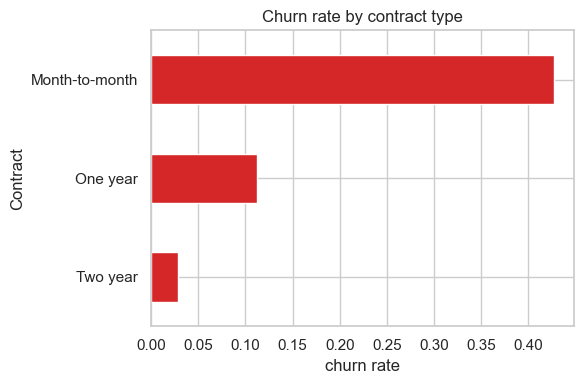

In [8]:
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index").rename(
    columns={0: "stay", 1: "churn"})
print(ct)

fig, ax = plt.subplots(figsize=(6, 4))
ct["churn"].sort_values().plot(kind="barh", color="#d62728", ax=ax)
ax.set_title("Churn rate by contract type")
ax.set_xlabel("churn rate")
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_by_contract.png", dpi=120)
plt.show()

**Finding.** Month-to-month customers churn at **~43%**; one-year at ~11%; two-year
at ~3%. Contract length is one of the cleanest separators in the data.

**Modeling implication.** A high-signal, low-cardinality categorical — exactly what
one-hot encoding handles well. Expect `Contract` (and its month-to-month level) to rank
near the top of SHAP importance; if it doesn't, something is wrong with the pipeline.

## 6. Monthly charges, internet service, and payment method

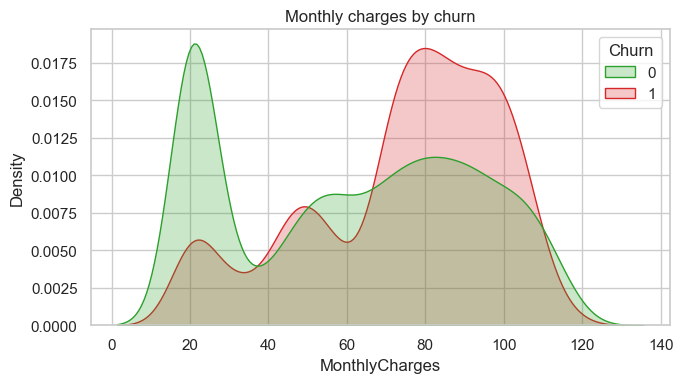

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
# common_norm=False again: each churn group integrates to 1 on its own, so the smaller churn
# class is not dwarfed by the larger stay class and we can compare the two spending shapes.
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False,
            palette={0: "#2ca02c", 1: "#d62728"}, ax=ax)
ax.set_title("Monthly charges by churn")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthlycharges_by_churn.png", dpi=120)
plt.show()

In [10]:
for col in ["InternetService", "PaymentMethod"]:
    rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(f"--- churn rate by {col} ---")
    print(rate.to_string(), "\n")

--- churn rate by InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050 

--- churn rate by PaymentMethod ---
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431 



**Finding.**
- **Monthly charges:** churners skew toward higher bills; there is a pronounced churn bump
  in the ~$70–$100 range (largely the fiber cohort).
- **Internet service:** **Fiber optic** customers churn far more (~42%) than DSL (~19%) or
  no-internet (~7%) — likely price/expectation sensitivity.
- **Payment method:** **Electronic check** stands out (~45% churn) versus automatic
  bank/card payments (~15%). Payment friction tracks with leaving.

**Modeling implication.** These confirm several strong categorical signals. Note the
correlation between fiber, higher MonthlyCharges, and churn — the model must not be read as
implying independent effects; SHAP dependence plots in `evaluate.py` untangle them.

## 7. Correlations among the numeric features

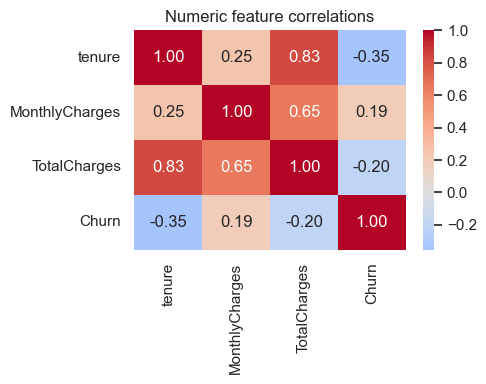

In [11]:
num = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
corr = num.corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric feature correlations")
fig.tight_layout()
fig.savefig(FIG_DIR / "numeric_correlations.png", dpi=120)
plt.show()

**Finding.** `TotalCharges` is highly correlated with `tenure` (long-tenured
customers have paid more in total) and with `MonthlyCharges`. `tenure` has the strongest
(negative) correlation with churn among the numerics.

**Modeling implication.** `TotalCharges` is partly redundant with tenure*monthly. We keep
it (it carries some independent signal and trees are robust to correlated inputs), but this
collinearity is why we lean on the **regularized** logistic baseline and on SHAP — rather
than raw coefficients — to talk about feature effects.

## 8. Summary — EDA to modeling decisions

| Finding | Decision it drives |
|---|---|
| 26.5% churn (imbalanced) | PR-AUC headline (not accuracy); class weighting; stratified splits |
| 11 blank TotalCharges, all tenure=0 | Fill with 0 (true value), not the mean |
| Churn is front-loaded in tenure | Tree models for non-linearity; threshold tuned for early-churn capture |
| Contract / fiber / e-check strong separators | One-hot encoding; expect them atop SHAP |
| tenure–TotalCharges–MonthlyCharges collinear | Regularized LR baseline; explain via SHAP, not raw coefficients |
| Add-on services relate to stickiness | Engineered `num_addon_services` count feature |

The cleaning lives in `src/data.py`, the leakage-safe preprocessing in `src/features.py`,
and training/evaluation in `src/train.py` / `src/evaluate.py`.